# 01 — Data Cleaning, Kết Nối Bảng & Dán Nhãn Rủi Ro
**Dataset:** Open University Learning Analytics Dataset (OULAD)  
**Mục tiêu:** Làm sạch dữ liệu → Ghép bảng → Feature engineering → Gán nhãn 4 mức rủi ro  
**Output:** `data/processed/student_features_labeled.csv`

---
### Nội dung notebook
1. Xác định bài toán và cấu trúc dữ liệu  
2. Load & kiểm tra từng bảng  
3. Làm sạch dữ liệu (missing values, outliers, encoding)  
4. Kết nối bảng (JOIN)  
5. Feature engineering từ VLE & Assessment  
6. Gán nhãn mức rủi ro (4 lớp)  
7. Phân tích imbalance  
8. Lưu file processed

## 0. Setup & Import

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Đường dẫn dữ liệu ──────────────────────────────────────────────────────────
RAW_DIR       = '../data/raw/'          # chỉnh nếu chạy từ thư mục khác
PROCESSED_DIR = '../data/processed/'
os.makedirs(PROCESSED_DIR, exist_ok=True)

print('Setup hoàn tất')
print(f'   RAW_DIR       : {os.path.abspath(RAW_DIR)}')
print(f'   PROCESSED_DIR : {os.path.abspath(PROCESSED_DIR)}')

Setup hoàn tất
   RAW_DIR       : c:\Năm 3 kì 2\Thực tập cơ sở\Dataset\data\raw
   PROCESSED_DIR : c:\Năm 3 kì 2\Thực tập cơ sở\Dataset\data\processed


---
## 1. Xác Định Bài Toán & Cấu Trúc Dữ Liệu

| Bảng | Mô tả | Key |
|---|---|---|
| `studentInfo.csv` | Thông tin nhân khẩu + kết quả cuối | `id_student`, `code_module`, `code_presentation` |
| `studentAssessment.csv` | Điểm từng bài kiểm tra | `id_assessment`, `id_student` |
| `assessments.csv` | Metadata bài kiểm tra (loại, trọng số) | `id_assessment` |
| `studentVle.csv` | Lượt click VLE theo ngày | `id_student`, `id_site` |
| `studentRegistration.csv` | Ngày đăng ký / hủy đăng ký | `id_student` |

**Mục tiêu phân loại:**  
- `0` — **Low** (nguy cơ thấp)  
- `1` — **Medium** (trung bình)  
- `2` — **High** (cao)  
- `3` — **Very High** (rất cao)

---
## 2. Load & Kiểm Tra Từng Bảng

In [38]:
# ── Load tất cả bảng ───────────────────────────────────────────────────────────
student_info  = pd.read_csv(RAW_DIR + 'studentInfo.csv')
student_asmt  = pd.read_csv(RAW_DIR + 'studentAssessment.csv')
assessments   = pd.read_csv(RAW_DIR + 'assessments.csv')
student_vle   = pd.read_csv(RAW_DIR + 'studentVle.csv')
student_reg   = pd.read_csv(RAW_DIR + 'studentRegistration.csv')
vle           = pd.read_csv(RAW_DIR + 'vle.csv')

tables = {
    'studentInfo'       : student_info,
    'studentAssessment' : student_asmt,
    'assessments'       : assessments,
    'studentVle'        : student_vle,
    'studentRegistration': student_reg,
    'vle'               : vle
}

for name, df in tables.items():
    print(f'📄 {name:25s} | shape: {str(df.shape):15s} | cols: {list(df.columns)}')

📄 studentInfo               | shape: (32593, 12)     | cols: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
📄 studentAssessment         | shape: (173912, 5)     | cols: ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']
📄 assessments               | shape: (206, 6)        | cols: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
📄 studentVle                | shape: (10655280, 6)   | cols: ['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']
📄 studentRegistration       | shape: (32593, 5)      | cols: ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']
📄 vle                       | shape: (6364, 6)       | cols: ['id_site', 'code_module', 'code_presentation', 'activity_type', 'week_from', 'week_to']


In [39]:
# ── Xem mẫu studentInfo ───────────────────────────────────────────────────────
print('=== studentInfo — 5 dòng đầu ===')
display(student_info.head())
print('\n=== Phân phối final_result ===')
print(student_info['final_result'].value_counts())
print(f'\nTổng sinh viên unique: {student_info["id_student"].nunique():,}')

=== studentInfo — 5 dòng đầu ===


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass



=== Phân phối final_result ===
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

Tổng sinh viên unique: 28,785


In [40]:
# ── Kiểm tra missing values toàn bộ bảng ──────────────────────────────────────
print('=== Missing Values Summary ===')
for name, df in tables.items():
    missing = df.isnull().sum()
    if missing.any():
        print(f'\n[{name}]')
        print(missing[missing > 0].to_string())
    else:
        print(f'[{name}] Không có missing')

=== Missing Values Summary ===

[studentInfo]
imd_band    1111

[studentAssessment]
score    173

[assessments]
date    11
[studentVle] Không có missing

[studentRegistration]
date_registration         45
date_unregistration    22521

[vle]
week_from    5243
week_to      5243


---
## 3. Làm Sạch Dữ Liệu

In [41]:
# ── 3.1 studentInfo — xử lý imd_band và các categorical ──────────────────────
print('Trước khi làm sạch:', student_info.shape)

# Mapping imd_band (Index of Multiple Deprivation) sang số thứ tự
imd_order = {
    '0-10%': 1, '10-20': 2, '20-30%': 3, '30-40%': 4, '40-50%': 5,
    '50-60%': 6, '60-70%': 7, '70-80%': 8, '80-90%': 9, '90-100%': 10
}
edu_order = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}
age_order = {'0-35': 0, '35-55': 1, '55<=': 2}

si = student_info.copy()

# Điền missing imd_band bằng median encoding
si['imd_band_num'] = si['imd_band'].map(imd_order)
si['imd_band_num'].fillna(si['imd_band_num'].median(), inplace=True)

# Ordinal encoding
si['education_num'] = si['highest_education'].map(edu_order)
si['age_num']       = si['age_band'].map(age_order)

# Binary encoding
si['gender_num']    = (si['gender'] == 'M').astype(int)
si['disability_num']= (si['disability'] == 'Y').astype(int)

print('Sau khi làm sạch:', si.shape)
print('\nCác cột mới:', ['imd_band_num','education_num','age_num','gender_num','disability_num'])

Trước khi làm sạch: (32593, 12)
Sau khi làm sạch: (32593, 17)

Các cột mới: ['imd_band_num', 'education_num', 'age_num', 'gender_num', 'disability_num']


In [42]:
# ── 3.2 studentAssessment — xử lý missing score và is_banked ─────────────────
sa = student_asmt.copy()

print(f'Tổng bản ghi assessment: {len(sa):,}')
print(f'Missing score: {sa["score"].isnull().sum():,} ({sa["score"].isnull().mean()*100:.1f}%)')

# Score null = không nộp bài → xem như 0
sa['score'].fillna(0, inplace=True)
sa['submitted'] = (~student_asmt['score'].isnull()).astype(int)  # flag nộp hay không

# Loại bài "banked" từ kỳ trước (tránh data leakage)
sa = sa[sa['is_banked'] == 0].copy()
print(f'Sau khi loại banked: {len(sa):,}')

Tổng bản ghi assessment: 173,912
Missing score: 173 (0.1%)
Sau khi loại banked: 172,003


In [43]:
# ── 3.3 studentRegistration — tính ngày đăng ký sớm/muộn ─────────────────────
reg = student_reg.copy()

# Ngày đăng ký âm = đăng ký trước khi khóa bắt đầu (tốt)
reg['early_registration'] = (reg['date_registration'] < 0).astype(int)
reg['reg_days_before']    = reg['date_registration'].clip(upper=0).abs()  # bao nhiêu ngày trước

# Đã hủy đăng ký chưa
reg['unregistered'] = (~reg['date_unregistration'].isnull()).astype(int)

print(reg[['early_registration','reg_days_before','unregistered']].describe())

       early_registration  reg_days_before  unregistered
count            32593.00         32548.00      32593.00
mean                 0.99            69.50          0.31
std                  0.09            49.10          0.46
min                  0.00             0.00          0.00
25%                  1.00            29.00          0.00
50%                  1.00            57.00          0.00
75%                  1.00           100.00          1.00
max                  1.00           322.00          1.00


---
## 4. Feature Engineering
### 4.1 Features từ VLE (hành vi tương tác)

In [44]:
# ── Aggregate studentVle theo sinh viên + module + presentation ───────────────
vle_features = student_vle.groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg(
    total_clicks    = ('sum_click', 'sum'),        # tổng lượt click
    active_days     = ('date', 'nunique'),          # số ngày có tương tác
    avg_clicks_day  = ('sum_click', 'mean'),        # click trung bình/ngày
    max_clicks_day  = ('sum_click', 'max'),         # ngày bận nhất
    n_resources     = ('id_site', 'nunique'),       # số tài nguyên khác nhau đã xem
).reset_index()

# Click density = tổng click / số ngày hoạt động
vle_features['click_density'] = (
    vle_features['total_clicks'] / vle_features['active_days'].clip(lower=1)
)

print(f'VLE features shape: {vle_features.shape}')
display(vle_features.describe())

VLE features shape: (29228, 9)


,id_student,total_clicks,active_days,avg_clicks_day,max_clicks_day,n_resources,click_density
count,29228.00,29228.00,29228.00,29228.00,29228.00,29228.00,29228.00
mean,708336.68,1355.04,61.86,3.27,53.14,67.08,19.04
std,551736.16,1733.55,54.03,1.23,95.45,54.95,11.58
min,6516.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,507576.75,260.75,18.00,2.36,16.00,27.00,11.21
50%,589828.00,739.50,47.00,3.08,34.00,51.00,16.36
75%,643706.75,1770.00,92.00,4.00,72.00,93.00,24.41
max,2698588.00,24139.00,286.00,20.03,6977.00,413.00,221.20


### 4.2 Features từ Assessment (điểm & hành vi nộp bài)

In [45]:
# ── Join assessment với metadata để phân loại TMA/CMA/Exam ───────────────────
sa_full = sa.merge(assessments, on='id_assessment', how='left')

# Tính submission delay (nộp sớm/muộn so với deadline)
sa_full['submit_delay'] = sa_full['date_submitted'] - sa_full['date']
# Âm = nộp trước deadline, Dương = nộp muộn
sa_full['late_submission'] = (sa_full['submit_delay'] > 0).astype(int)

# Aggregate theo sinh viên + module + presentation
asmt_features = sa_full.groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg(
    avg_score          = ('score', 'mean'),
    min_score          = ('score', 'min'),
    std_score          = ('score', 'std'),
    n_submitted        = ('submitted', 'sum'),
    n_late             = ('late_submission', 'sum'),
    avg_submit_delay   = ('submit_delay', 'mean'),
).reset_index()

# TMA score riêng (bài giáo viên chấm — thường quan trọng hơn)
tma_scores = sa_full[sa_full['assessment_type'] == 'TMA'].groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg(avg_tma_score=('score', 'mean')).reset_index()

asmt_features = asmt_features.merge(tma_scores, on=['id_student','code_module','code_presentation'], how='left')
asmt_features['avg_tma_score'].fillna(asmt_features['avg_score'], inplace=True)
asmt_features['std_score'].fillna(0, inplace=True)

print(f'Assessment features shape: {asmt_features.shape}')
display(asmt_features.describe())

Assessment features shape: (25580, 10)


,id_student,avg_score,min_score,std_score,n_submitted,n_late,avg_submit_delay,avg_tma_score
count,25580.00,25580.00,25580.00,25580.00,25580.00,25580.00,25569.00,25580.00
mean,707855.78,72.59,55.37,12.01,6.72,1.93,-11.01,70.50
std,553031.39,16.67,22.58,8.37,3.78,2.31,25.29,16.98
min,6516.00,0.00,0.00,0.00,0.00,0.00,-236.00,0.00
25%,506122.00,64.42,41.00,6.30,4.00,0.00,-8.00,61.50
50%,589482.00,76.00,60.00,11.07,7.00,1.00,-0.50,73.00
75%,642993.25,84.50,72.00,16.57,10.00,4.00,1.50,82.67
max,2698588.00,100.00,100.00,70.71,14.00,12.00,187.00,100.00


---
## 5. Kết Nối Bảng (Final JOIN)

In [46]:
# ── Chọn cột cần thiết từ studentInfo ────────────────────────────────────────
si_cols = [
    'id_student', 'code_module', 'code_presentation',
    'gender_num', 'imd_band_num', 'education_num',
    'age_num', 'disability_num',
    'num_of_prev_attempts', 'studied_credits',
    'final_result'
]
base = si[si_cols].copy()

# ── Chọn cột registration ─────────────────────────────────────────────────────
reg_cols = [
    'id_student', 'code_module', 'code_presentation',
    'early_registration', 'reg_days_before', 'unregistered'
]

# ── JOIN tuần tự ──────────────────────────────────────────────────────────────
join_keys = ['id_student', 'code_module', 'code_presentation']

df = base.merge(reg[reg_cols],    on=join_keys, how='left')
df = df.merge(vle_features,       on=join_keys, how='left')
df = df.merge(asmt_features,      on=join_keys, how='left')

print(f' DataFrame sau JOIN: {df.shape}')
print(f' Số sinh viên: {df["id_student"].nunique():,}')
print(f'\n=== Missing Values sau JOIN ===')
missing_final = df.isnull().sum()
print(missing_final[missing_final > 0])

 DataFrame sau JOIN: (32593, 27)
 Số sinh viên: 28,785

=== Missing Values sau JOIN ===
reg_days_before       45
total_clicks        3365
active_days         3365
avg_clicks_day      3365
max_clicks_day      3365
n_resources         3365
click_density       3365
avg_score           7013
min_score           7013
std_score           7013
n_submitted         7013
n_late              7013
avg_submit_delay    7024
avg_tma_score       7013
dtype: int64


In [47]:
# ── Điền missing sau JOIN (sv chưa tương tác VLE hoặc chưa nộp bài) ──────────
vle_fill_cols  = ['total_clicks','active_days','avg_clicks_day','max_clicks_day',
                   'n_resources','click_density']
asmt_fill_cols = ['avg_score','min_score','std_score','n_submitted','n_late',
                   'avg_submit_delay','avg_tma_score']
reg_fill_cols  = ['early_registration','reg_days_before','unregistered']

# VLE null = không tương tác → 0
df[vle_fill_cols] = df[vle_fill_cols].fillna(0)
# Assessment null = chưa nộp bài → score 0
df[asmt_fill_cols] = df[asmt_fill_cols].fillna(0)
# Registration null → 0
df[reg_fill_cols] = df[reg_fill_cols].fillna(0)

print('Missing values sau xử lý:', df.isnull().sum().sum())
print(f'Shape cuối: {df.shape}')

Missing values sau xử lý: 0
Shape cuối: (32593, 27)


---
## 6. Gán Nhãn Mức Rủi Ro (4 Lớp)

**Logic gán nhãn tổng hợp** — kết hợp `final_result`, điểm và hành vi VLE:

| Mức | Nhãn | Điều kiện |
|---|---|---|
| 3 | Very High | `final_result` = Fail hoặc Withdrawn |
| 2 | High | Pass nhưng avg_score < 55 hoặc total_clicks < 100 |
| 1 | Medium | Pass nhưng avg_score < 70 hoặc avg_tma_score < 65 |
| 0 | Low | Pass/Distinction với điểm và tương tác tốt |

In [48]:
def assign_risk_label(row):
    """
    Gán nhãn rủi ro 4 mức dựa trên kết quả + hành vi học tập.
    
    Trả về:
        0 = Low (Nguy cơ thấp)
        1 = Medium (Trung bình)
        2 = High (Cao)
        3 = Very High (Rất cao)
    """
    result = row['final_result']
    score  = row['avg_score']
    clicks = row['total_clicks']
    tma    = row['avg_tma_score']
    late   = row['n_late']
    active = row['active_days']

    # ── Mức 3: Rất cao ─────────────────────────────────────────────────────────
    if result in ['Fail', 'Withdrawn']:
        return 3

    # ── Mức 2: Cao ─────────────────────────────────────────────────────────────
    # Pass nhưng điểm rất thấp hoặc gần như không tương tác VLE
    if score < 55 or clicks < 100 or active < 5:
        return 2

    # ── Mức 1: Trung bình ──────────────────────────────────────────────────────
    # Pass nhưng điểm biên hoặc TMA yếu hoặc nhiều bài nộp muộn
    if score < 70 or tma < 65 or (late >= 2 and score < 75):
        return 1

    # ── Mức 0: Thấp ────────────────────────────────────────────────────────────
    return 0


df['risk_level'] = df.apply(assign_risk_label, axis=1)

# Label text tương ứng
risk_labels = {0: 'Low', 1: 'Medium', 2: 'High', 3: 'Very High'}
df['risk_label'] = df['risk_level'].map(risk_labels)

print('✅ Gán nhãn hoàn tất')
print('\n=== Phân phối nhãn ===')
counts = df['risk_label'].value_counts()
pct    = df['risk_label'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'count': counts, 'pct': pct.round(1)})
print(summary)

✅ Gán nhãn hoàn tất

=== Phân phối nhãn ===
            count   pct
risk_label             
Very High   17208 52.80
Low         10904 33.50
Medium       3865 11.90
High          616  1.90


---
## 7. Phân Tích Imbalance

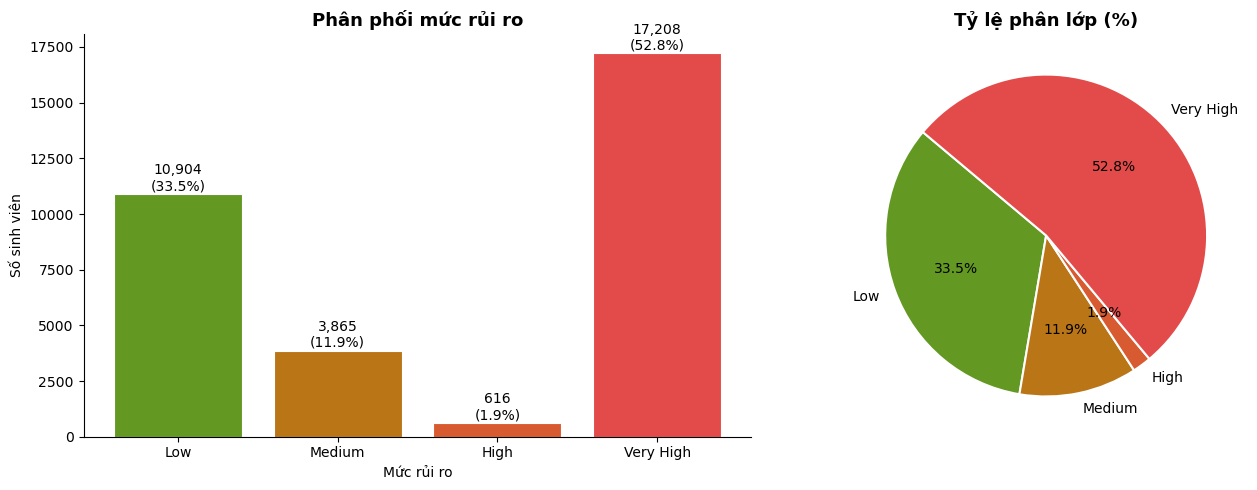

Biểu đồ đã lưu → visuals/01_class_distribution.png


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#639922', '#BA7517', '#D85A30', '#E24B4A']
order  = ['Low', 'Medium', 'High', 'Very High']

# ── Bar chart phân phối ───────────────────────────────────────────────────────
ax1 = axes[0]
cnt = df['risk_label'].value_counts().reindex(order)
bars = ax1.bar(order, cnt.values, color=colors, edgecolor='white', linewidth=0.8)
ax1.set_title('Phân phối mức rủi ro', fontsize=13, fontweight='bold')
ax1.set_xlabel('Mức rủi ro')
ax1.set_ylabel('Số sinh viên')
for bar, val in zip(bars, cnt.values):
    pct_val = val / len(df) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({pct_val:.1f}%)', ha='center', va='bottom', fontsize=10)
ax1.spines[['top','right']].set_visible(False)

# ── Pie chart ─────────────────────────────────────────────────────────────────
ax2 = axes[1]
pct_vals = df['risk_label'].value_counts(normalize=True).reindex(order) * 100
wedges, texts, autotexts = ax2.pie(
    pct_vals.values, labels=order, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax2.set_title('Tỷ lệ phân lớp (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Biểu đồ đã lưu → visuals/01_class_distribution.png')

In [50]:
# ── Imbalance ratio ───────────────────────────────────────────────────────────
print('=== Imbalance Analysis ===')
value_counts = df['risk_level'].value_counts().sort_index()
majority = value_counts.max()
minority = value_counts.min()
imbalance_ratio = majority / minority

print(f'Lớp đa số (majority): {majority:,}')
print(f'Lớp thiểu số (minority): {minority:,}')
print(f'Imbalance ratio: {imbalance_ratio:.1f}:1')

if imbalance_ratio > 5:
    print('\n Imbalance NGHIÊM TRỌNG — cần xử lý SMOTE/class_weight')
elif imbalance_ratio > 3:
    print('\n Imbalance TRUNG BÌNH — nên dùng class_weight')
else:
    print('\n Imbalance nhẹ — class_weight là đủ')

print('\n=== Gợi ý chiến lược xử lý ===')
print('1. SMOTE (imblearn)    — tạo mẫu tổng hợp cho lớp thiểu số')
print('2. class_weight=balanced — điều chỉnh loss function')
print('3. BalancedRandomForest — ensemble tích hợp cân bằng')
print('4. SMOTETomek          — oversample + clean borderline')

=== Imbalance Analysis ===
Lớp đa số (majority): 17,208
Lớp thiểu số (minority): 616
Imbalance ratio: 27.9:1

 Imbalance NGHIÊM TRỌNG — cần xử lý SMOTE/class_weight

=== Gợi ý chiến lược xử lý ===
1. SMOTE (imblearn)    — tạo mẫu tổng hợp cho lớp thiểu số
2. class_weight=balanced — điều chỉnh loss function
3. BalancedRandomForest — ensemble tích hợp cân bằng
4. SMOTETomek          — oversample + clean borderline


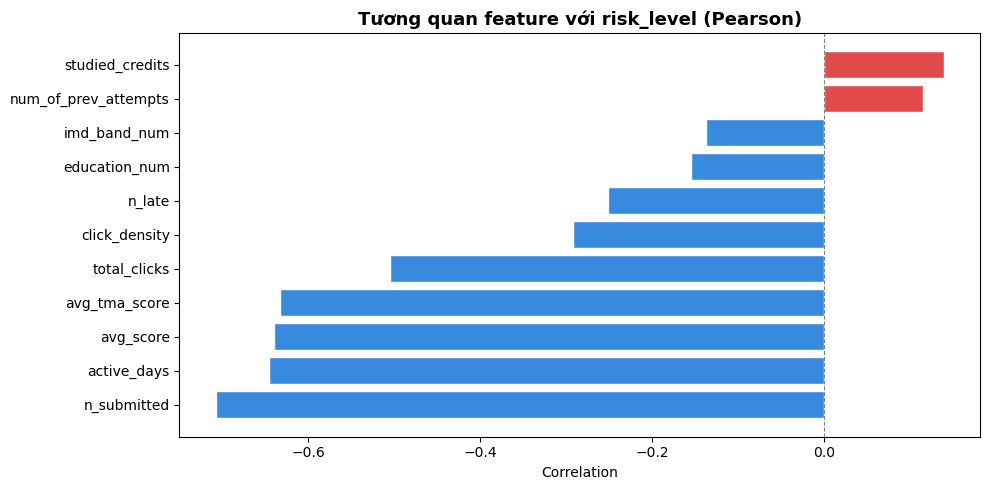

 Biểu đồ đã lưu → visuals/02_feature_correlation.png


In [51]:
# ── Feature correlation với risk_level ───────────────────────────────────────
feature_cols = [
    'avg_score', 'avg_tma_score', 'total_clicks', 'active_days',
    'n_submitted', 'n_late', 'click_density', 'education_num',
    'imd_band_num', 'num_of_prev_attempts', 'studied_credits'
]

corr_with_risk = df[feature_cols + ['risk_level']].corr()['risk_level'].drop('risk_level').sort_values()

plt.figure(figsize=(10, 5))
colors_bar = ['#E24B4A' if x > 0 else '#378ADD' for x in corr_with_risk]
plt.barh(corr_with_risk.index, corr_with_risk.values, color=colors_bar, edgecolor='white')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Tương quan feature với risk_level (Pearson)', fontsize=13, fontweight='bold')
plt.xlabel('Correlation')
plt.tight_layout()
plt.savefig('../visuals/02_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Biểu đồ đã lưu → visuals/02_feature_correlation.png')

---
## 8. Lưu File Processed

In [52]:
# ── Chọn feature set cuối cùng ───────────────────────────────────────────────
FEATURE_COLS = [
    # Nhân khẩu học
    'gender_num', 'imd_band_num', 'education_num', 'age_num',
    'disability_num', 'num_of_prev_attempts', 'studied_credits',
    # Đăng ký
    'early_registration', 'reg_days_before', 'unregistered',
    # VLE behavior
    'total_clicks', 'active_days', 'avg_clicks_day',
    'max_clicks_day', 'n_resources', 'click_density',
    # Assessment
    'avg_score', 'min_score', 'std_score', 'avg_tma_score',
    'n_submitted', 'n_late', 'avg_submit_delay',
]

ID_COLS     = ['id_student', 'code_module', 'code_presentation']
TARGET_COLS = ['risk_level', 'risk_label', 'final_result']

df_final = df[ID_COLS + FEATURE_COLS + TARGET_COLS].copy()

# ── Lưu file ──────────────────────────────────────────────────────────────────
out_path = PROCESSED_DIR + 'student_features_labeled.csv'
df_final.to_csv(out_path, index=False)

print(f'Đã lưu: {out_path}')
print(f'   Shape   : {df_final.shape}')
print(f'   Features: {len(FEATURE_COLS)} cột')
print(f'\n=== 5 dòng cuối ===')
display(df_final.tail())

print('\n=== Phân phối nhãn cuối cùng ===')
print(df_final['risk_label'].value_counts())

Đã lưu: ../data/processed/student_features_labeled.csv
   Shape   : (32593, 29)
   Features: 23 cột

=== 5 dòng cuối ===


,id_student,code_module,code_presentation,gender_num,imd_band_num,education_num,age_num,disability_num,num_of_prev_attempts,studied_credits,early_registration,reg_days_before,unregistered,total_clicks,active_days,avg_clicks_day,max_clicks_day,n_resources,click_density,avg_score,min_score,std_score,avg_tma_score,n_submitted,n_late,avg_submit_delay,risk_level,risk_label,final_result
32588,2640965,GGG,2014J,0,2.00,1,0,0,0,30,1,4.00,0,41.00,5.00,2.16,11.00,8.00,8.20,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3,Very High,Fail
32589,2645731,GGG,2014J,0,5.00,1,1,0,0,30,1,23.00,0,893.00,45.00,3.77,34.00,50.00,19.84,88.11,72.00,11.58,77.67,9.00,2.00,-36.22,0,Low,Distinction
32590,2648187,GGG,2014J,0,3.00,2,0,1,0,30,1,129.00,0,312.00,24.00,2.89,23.00,28.00,13.00,76.67,60.00,15.21,70.00,9.00,0.00,-45.33,0,Low,Pass
32591,2679821,GGG,2014J,0,10.00,1,1,0,0,30,1,49.00,1,275.00,13.00,4.51,24.00,17.00,21.15,91.50,83.00,12.02,83.00,2.00,0.00,-79.50,3,Very High,Withdrawn
32592,2684003,GGG,2014J,0,6.00,3,1,0,0,30,1,28.00,0,616.00,34.00,3.40,31.00,32.00,18.12,82.86,60.00,17.99,73.33,7.00,0.00,-50.43,0,Low,Distinction



=== Phân phối nhãn cuối cùng ===
risk_label
Very High    17208
Low          10904
Medium        3865
High           616
Name: count, dtype: int64


---
## Tóm Tắt Bước 01

| Hạng mục | Chi tiết |
|---|---|
| Bảng đã xử lý | studentInfo, studentAssessment, assessments, studentVle, studentRegistration |
| Số features tạo ra | 23 features |
| Logic gán nhãn | final_result + avg_score + total_clicks + avg_tma_score + n_late |
| Output | `data/processed/student_features_labeled.csv` |
| Biểu đồ | `visuals/01_class_distribution.png`, `visuals/02_feature_correlation.png` |

**Bước tiếp theo →** `02_eda_and_imbalance.ipynb`  
- EDA chi tiết từng feature  
- So sánh SMOTE / class_weight / BalancedEnsemble  
- Train/val/test split có stratify